# HW3 Image Classification
## We strongly recommend that you run with [Kaggle](https://www.kaggle.com/t/86ca241732c04da99aca6490080bae73) for this homework

If you have any questions, please contact the TAs via TA hours, NTU COOL, or email to mlta-2023-spring@googlegroups.com

# Check GPU Type

In [1]:
#!nvidia-smi

# Get Data
Notes: if the links are dead, you can download the data directly from Kaggle and upload it to the workspace, or you can use the Kaggle API to directly download the data into colab.


In [2]:
# Download Link
# Link 1 (Dropbox): https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=0
# Link 2 (Google Drive): https://drive.google.com/file/d/1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9/view?usp=share_link
# Link 3: Kaggle Competition.

# (1) dropbox link
# !wget -O food11.zip https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=0

# (2) google drive link
# !pip install gdown --upgrade
# !gdown --id '1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9' --output food11.zip
#!megadl "https://mega.nz/#!zt1TTIhK!ZuMbg5ZjGWzWX1I6nEUbfjMZgCmAgeqJlwDkqdIryfg"


In [3]:
# ! unzip food11.zip

# Import Packages

In [4]:
# Define your log filename
_exp_name = "sample"
training_labeled_path = "./food/training/labeled"
validation_path = "./food/validation"
testing_path = "./food/testing/00"

In [5]:
# Import necessary packages.
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
# "ConcatDataset" and "Subset" are possibly useful when doing semi-supervised learning.
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
# Pretrained model
from torchvision.models import resnet18, resnet50, vgg16, densenet121, alexnet, squeezenet1_0, efficientnet
# This is for the progress bar.
from tqdm.auto import tqdm
import random
# For plotting learning curve
from torch.utils.tensorboard import SummaryWriter
# K-fold cross validation and boosting
from sklearn.model_selection import KFold
from sklearn.ensemble import AdaBoostClassifier

import json

/home/m/miniconda3/envs/env_demo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
myseed = 3407  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms
Torchvision provides lots of useful utilities for image preprocessing, data *wrapping* as well as data augmentation.

Please refer to PyTorch official website for details about different transforms.

In [7]:
# Normally, We don't need augmentations in testing and validation.
# All we need here is to resize the PIL image and transform it into Tensor.
test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# However, it is also possible to use augmentation in the testing phase.
# You may use train_tfm to produce a variety of images and then test using ensemble methods

train_tfm = transforms.Compose([
    # Resize the image into a fixed shape (height = width = 128)
    transforms.Resize((128, 128)),
    # You may add some transforms here.
    
    transforms.RandomChoice(transforms=[
        # Apply TrivialAugmentWide data augmentation method
        transforms.TrivialAugmentWide(),

        # Return original image
        transforms.Lambda(lambda x: x),
    ],
                            p=[0.95, 0.05]),

    # ToTensor() should be the last one of the transfo·rms.
    transforms.ToTensor(),
])

# Q1. Augmentation Implementation Visualization

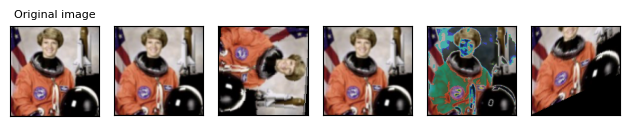

In [8]:
# I want to show you an example code of Q1. Augmentation Implementation that visualizes the effects of different image transformations.
import matplotlib.pyplot as plt

plt.rcParams["savefig.bbox"] = 'tight'

# You can change the file path to match your image
orig_img = Image.open('Q1/assets/astronaut.jpg')


def plot(imgs, with_orig=True, row_title=None, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0]) + with_orig
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        row = [orig_img] + row if with_orig else row
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    if with_orig:
        axs[0, 0].set(title='Original image')
        axs[0, 0].title.set_size(8)
    if row_title is not None:
        for row_idx in range(num_rows):
            axs[row_idx, 0].set(ylabel=row_title[row_idx])

    plt.tight_layout()

# Create a list of five transformed images from the original image using the train_tfm function
demo = [train_tfm(orig_img) for i in range(5)]

# Convert the transformed images from tensors to PIL images
pil_img_demo = [Image.fromarray(np.moveaxis(img.numpy()*255, 0, -1).astype(np.uint8)) for img in demo]

# Plot the transformed images using the plot function
plot(pil_img_demo) 

# Datasets
The data is labelled by the name, so we load images and label while calling '__getitem__'

In [9]:
class FoodDataset(Dataset):
    """
    定义一个继承自Dataset的FoodDataset类，用于处理食物图片数据集。
    
    参数:
    - path: 图片数据集的路径。
    - tfm: 图片变换方法，默认为test_tfm。
    - files: 图片文件路径列表，默认为None。如果提供该参数，则使用该列表作为图片文件路径。
    """
    def __init__(self, path, tfm=test_tfm, files=None):
        super(FoodDataset, self).__init__()  # 初始化父类Dataset
        self.path = path
        # 获取路径下所有.jpg结尾的文件，并按字母顺序排序
        self.files = sorted([os.path.join(path, x) for x in os.listdir(path) if x.endswith(".jpg")])
        if files is not None:  # 如果提供了files参数，则使用该参数值
            self.files = files
        self.transform = tfm  # 保存图片变换方法

    def __len__(self):
        """
        返回数据集的大小，即图片文件的数量。
        """
        return len(self.files)

    def __getitem__(self, idx):
        """
        根据索引idx获取并返回一张图片及其标签。
        
        参数:
        - idx: 图片的索引。
        
        返回:
        - im: 变换后的图片。
        - label: 图片对应的标签，如果无法获取标签则返回-1。
        """
        fname = self.files[idx]  # 获取文件名
        im = Image.open(fname)  # 打开图片
        im = self.transform(im)  # 对图片进行变换
        
        # 尝试从文件名中提取标签，如果失败则标签为-1
        try:
            label = int(fname.split("/")[-1].split("_")[0])
        except:
            label = -1
            
        return im, label


class MySubset(Subset):
    """
    定义一个继承自Subset的MySubset类，用于处理数据集的子集。
    
    参数:
    - dataset: 原始数据集对象。
    - indices: 子集的索引列表。
    - tfm: 图片变换方法，默认为test_tfm。
    """
    def __init__(self, dataset, indices, tfm=test_tfm):
        super().__init__(dataset, indices)  # 初始化父类Subset
        self.transform = tfm  # 保存图片变换方法

    def __getitem__(self, idx):
        """
        根据索引idx获取并返回子集中对应的数据项。
        
        参数:
        - idx: 数据项的索引。
        
        返回:
        - 如果idx是列表，则返回一个数据项列表，每个数据项是原始数据集中对应索引的数据。
        - 如果idx是单个索引，则返回单个数据项，包括变换后的图片和标签。
        """
        if isinstance(idx, list):  # 如果idx是列表，则返回对应索引的数据项列表
            return self.dataset[[self.indices[i] for i in idx]]
        self.dataset.transform = self.transform  # 设置数据集的变换方法
        return self.dataset[self.indices[idx]]  # 返回单个数据项
        

# Model

In [10]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        # torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        # torch.nn.MaxPool2d(kernel_size, stride, padding)
        # input 維度 [3, 128, 128]
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),  # 输入通道数为3，输出通道数为64，卷积核大小为3x3，步长为1，填充为1
            nn.BatchNorm2d(64),         # 对64通道的数据进行批归一化
            nn.ReLU(),                  # 使用ReLU激活函数
            nn.MaxPool2d(2, 2, 0),      # 最大池化层，窗口大小为2x2，步长为2，不填充

            nn.Conv2d(64, 128, 3, 1, 1), # 输入通道数为64，输出通道数为128，卷积核大小为3x3，步长为1，填充为1
            nn.BatchNorm2d(128),         # 对128通道的数据进行批归一化
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.MaxPool2d(2, 2, 0),      # 最大池化层，窗口大小为2x2，步长为2，不填充

            nn.Conv2d(128, 256, 3, 1, 1), # 输入通道数为128，输出通道数为256，卷积核大小为3x3，步长为1，填充为1
            nn.BatchNorm2d(256),         # 对256通道的数据进行批归一化
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.MaxPool2d(2, 2, 0),      # 最大池化层，窗口大小为2x2，步长为2，不填充

            nn.Conv2d(256, 512, 3, 1, 1), # 输入通道数为256，输出通道数为512，卷积核大小为3x3，步长为1，填充为1
            nn.BatchNorm2d(512),         # 对512通道的数据进行批归一化
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.MaxPool2d(2, 2, 0),      # 最大池化层，窗口大小为2x2，步长为2，不填充
            
            nn.Conv2d(512, 512, 3, 1, 1), # 输入通道数为512，输出通道数为512，卷积核大小为3x3，步长为1，填充为1
            nn.BatchNorm2d(512),         # 对512通道的数据进行批归一化
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.MaxPool2d(2, 2, 0),      # 最大池化层，窗口大小为2x2，步长为2，不填充
        )
        self.fc = nn.Sequential(
            nn.Dropout(p=0.5),           # Dropout层，丢弃概率为0.5
            nn.Linear(512*4*4, 1024),    # 全连接层，输入大小为512*4*4，输出大小为1024
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.Dropout(p=0.5),           # Dropout层，丢弃概率为0.5
            nn.Linear(1024, 512),        # 全连接层，输入大小为1024，输出大小为512
            nn.ReLU(),                   # 使用ReLU激活函数
            nn.Dropout(p=0.5),           # Dropout层，丢弃概率为0.5
            nn.Linear(512, 11)           # 全连接层，输入大小为512，输出大小为11
        )
        

    def forward(self, x):
        out = self.cnn(x)
        out = out.view(out.size()[0], -1)
        return self.fc(out)

    
class ResNet50(nn.Module):
    """
    定义一个基于ResNet50的深度学习模型类。
    
    该类继承自nn.Module，主要做了以下修改：
    1. 移除了预训练权重。
    2. 去掉了原模型的全连接层部分。
    3. 添加了自定义的全连接层，以适应特定任务（最后输出11个类别）。
    """
    def __init__(self):
        """
        初始化ResNet50模型。
        
        包括：
        - 加载ResNet50模型的卷积部分，去除了最后一层全连接层。
        - 构建自定义全连接层，用于分类任务，输出维度为11。
        """
        super(ResNet50, self).__init__()
        # 加载ResNet50模型，去除最后一层全连接层
        self.cnn = nn.Sequential(*list(resnet50(weights=None).children())[:-1])
        # 获取ResNet50模型全连接层的输入特征数
        num_features = resnet50(weights=None).fc.in_features
        # 定义自定义全连接层
        self.fc = nn.Sequential(
            nn.Dropout(p=0.5),  # 随机失活，防止过拟合
            nn.Linear(num_features, 1024),  # 全连接层，从特征数到1024个节点
            nn.ReLU(),  # ReLU激活函数
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),  # 从1024个节点到512个节点
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 11)  # 从512个节点到11个输出类别
        )
        
    
    def forward(self, x):
        """
        实现前向传播过程
        
        参数:
        x (Tensor): 输入数据
        
        返回:
        Tensor: 经过卷积和全连接层处理后的输出
        """
        # 通过卷积神经网络处理输入x
        out = self.cnn(x)
        # 将卷积层的输出展平为一维向量，以适应全连接层的输入要求
        out = out.view(out.size()[0], -1)
        # 通过全连接层处理展平后的输出，并返回最终结果
        return self.fc(out)

    
class VGG16(nn.Module):
    """
    VGG16模型类，继承自nn.Module。
    用于图像分类任务，将VGG16的最后输出层修改为11类分类。
    """
    def __init__(self):
        """
        构造函数，初始化VGG16模型。
        """
        super(VGG16, self).__init__()
        # 加载VGG16模型结构，不包含预训练权重
        self.model = vgg16(weights=None)
        # 获取分类器中最后一个全连接层的输入特征数
        num_features = self.model.classifier[6].in_features
        # 替换最后一个全连接层，输出改为11类
        self.model.classifier[6] = nn.Linear(num_features, 11)
        # 设置模型的类别数为11
        self.model.num_classes = 11

    def forward(self, x):
        return self.model(x)


class DenseNet121(nn.Module):
    """
    创建一个修改过的DenseNet-121模型。
    
    该类继承自nn.Module，使用预定义的DenseNet-121架构，并在其末尾添加自定义分类器。
    """
    def __init__(self):
        """
        初始化DenseNet121模型。
        
        加载DenseNet-121的结构，移除其原始分类器，并根据需要替换为新的分类器。
        """
        super(DenseNet121, self).__init__()  # 初始化父类
        self.model = densenet121(weights=None)  # 加载DenseNet-121模型，不使用预训练权重
        num_features = self.model.classifier.in_features  # 获取原始分类器的输入特征数
        
        # 替换分类器为自定义的序列，包括多个全连接层和Dropout层
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),  # Dropout层，防止过拟合
            nn.Linear(num_features, 1024),  # 全连接层
            nn.ReLU(),  # 激活函数
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 11)  # 最终分类层，输出11个类别
        )

    def forward(self, x):
        return self.model(x)

class EfficientNet(nn.Module):
    """
    EfficientNet模型B6的定义。
    
    该类继承自nn.Module，重写了__init__和forward方法。
    在__init__方法中，加载了EfficientNet-B6模型的结构，并根据需要修改了分类器部分，
    以适应特定任务的输出类别数（11类）。
    """
    def __init__(self):
        super(EfficientNet, self).__init__()
        # 初始化EfficientNet-B6模型，不加载预训练权重
        self.model = efficientnet.efficientnet_b6(weights=None)
        # 获取分类器层的输入特征数
        num_features = self.model.classifier[1].in_features
        # 重写分类器层，添加自定义的全连接层和Dropout层，最终输出11类
        self.model.classifier[1] = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 11)
        )

    def forward(self, x):
        return self.model(x)

class AlexNet(nn.Module):
    """
    AlexNet模型的定义。
    
    该类继承自nn.Module，重写了__init__和forward方法。
    在__init__方法中，加载了AlexNet模型的结构，并根据需要修改了分类器部分，
    以适应特定任务的输出类别数（11类）。
    """
    def __init__(self):
        super(AlexNet, self).__init__()
        # 初始化AlexNet模型，不加载预训练权重
        self.model = alexnet(weights=None)
        # 获取分类器层的输入特征数
        num_features = self.model.classifier[6].in_features
        # 重写分类器层，添加自定义的全连接层，最终输出11类
        self.model.classifier[6] = nn.Linear(num_features, 11)
        self.model.num_classes = 11

    def forward(self, x):
        return self.model(x)
    
    
class SqueezeNet(nn.Module):
    """
    SqueezeNet模型的定义。
    
    该类继承自nn.Module，重写了__init__和forward方法。
    在__init__方法中，加载了SqueezeNet模型的结构，并根据需要修改了分类器部分，
    以适应特定任务的输出类别数（11类）。
    """
    def __init__(self):
        super(SqueezeNet, self).__init__()
        # 初始化SqueezeNet模型，不加载预训练权重
        self.model = squeezenet1_0(weights=None)
        # 获取分类器层的输入通道数
        num_features = self.model.classifier[1].in_channels
        # 重写分类器层，添加自定义的卷积层，最终输出11类
        self.model.classifier[1] = nn.Conv2d(num_features, 11, kernel_size=(1,1), stride=(1,1))#将第一次层卷及核大小改为1 步进为1
        self.model.num_classes = 11
        
    def forward(self, x):

        return self.model(x)
    
class EnsembleModel(nn.Module):
    """
    集成模型的定义。
    
    该类继承自nn.Module，重写了__init__和forward方法。
    在__init__方法中，初始化了一个包含多个基础模型的ModuleList。
    在forward方法中，实现了对这些基础模型的输出进行平均集成。
    
    参数:
    base_models (list): 包含多个基础模型的列表
    """
    def __init__(self, base_models):
        super(EnsembleModel, self).__init__()
        # 初始化基础模型列表
        self.base_models = nn.ModuleList(base_models)
        # 可以进一步定制分类器，但当前代码已注释掉
        # self.classifier = nn.Linear(len(base_models) * 11, 11)

    def forward(self, x):
        """
        定义模型的前向传播过程。
        
        参数:
        x (Tensor): 输入数据
        
        返回:
        Tensor: 集成模型的输出，通过对基础模型的输出求平均得到
        """
        # 获取每个基础模型的输出
        outputs = [model(x) for model in self.base_models]
        # 可以进一步处理outputs，例如使用分类器，但当前代码已注释掉
        # outputs = torch.cat(outputs, dim=1)
        # outputs = self.classifier(outputs)     
        # 将outputs在新的维度上堆叠并求平均
        outputs = torch.stack(outputs)
        outputs = torch.mean(outputs, dim=0)
        return outputs

# Configurations

In [11]:
# "cuda" only when GPUs are available.
# If you use apple chip (mac), you can change "cpu" to "mps"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize a model, and put it on the device specified.

model = Classifier().to(device)

# 定义一个变量Resume，用于决定是否从之前保存的最佳检查点中恢复模型
Resume = False

# 如果Resume为真，则加载之前保存的最佳模型权重
if Resume:
    # 使用torch.load方法从指定路径加载模型权重，并将其存储到GPU设备上
    # 这里使用了变量_exp_name来构建文件路径，具体实验名称应在此之前定义
    model.load_state_dict(torch.load(f"{_exp_name}_best.ckpt", map_location='cuda'))

# The number of batch size.
batch_size = 64

# The number of training epochs.
n_epochs = 200

# If no improvement in 'patience' epochs, early stop.
patience = 20

# For the classification task, we use cross-entropy as the measurement of performance.
# criterion = nn.CrossEntropyLoss()
# Label Smoothing Cross Entropy Loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Initialize optimizer, you may fine-tune some hyperparameters such as learning rate on your own.
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5) # 3e-4

# Create a learning rate scheduler that reduces the learning rate when the metric stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.8, patience=patience/2, threshold=0.05)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-8)

# Dataloader

In [12]:
# # Construct train and valid datasets.
# # The argument "loader" tells how torchvision reads the data.
train_set = FoodDataset(training_labeled_path, tfm=train_tfm)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_set = FoodDataset(validation_path, tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

# Start Training

## Cross validation
You can implement cross validation entirely using the cross_val_score in sklearn.model_selection, but I'll show you another way to implement it here.

In [13]:
import os
import shutil

# Check if the merge folder exists, if not, create it
merge_dir = "merge"
if not os.path.isdir(merge_dir):
    os.mkdir(merge_dir)

    # Get all the file names in the train and valid folders
    train_files = os.listdir(training_labeled_path)
    valid_files = os.listdir(validation_path)

    # Copy all the files in the train and valid folders to the merge folder
    for file in train_files:
        src_path = os.path.join(training_labeled_path, file)
        if os.path.isfile(src_path):
            shutil.copy(src_path, merge_dir)
    for file in valid_files:
        src_path = os.path.join(validation_path, file)
        if os.path.isfile(src_path):
            shutil.copy(src_path, merge_dir)

In [14]:
def stack(dataset, test_set, n_splits=5, models=[], tb=False):
    '''This function is a stacking function. Maybe not so standard :)

    Parameters:
        dataset: a torch.utils.data.Dataset object.
        test_set: a torch.utils.data.Dataset object for testing.
        n_splits (int): an integer that specifies the number of folds for cross-validation.
        models (list): a list of model classes to use for stacking. If empty, raise ValueError. 
                       If only one model, perform simple cross-validation and return avg_val_acc.
        tb (bool): a boolean that indicates whether to use tensorboard to log data.
    '''
    # Check if model is a list 
    if not isinstance(models, list):
        models = [models]
    # Check if models is empty
    elif not len(models):
        raise ValueError("models cannot be empty, you must specify a model.")
    
    
    ntrain = len(dataset)
    ntest = len(test_set)
    
    # Create a generator object G with a fixed seed myseed, which is used for train_loader
    G = torch.Generator()
    G.manual_seed(myseed)
    
    # Record out-of-flod prediction for models
    oof_dict = {}
    # Record CV scores for models
    val_acc_dict = {}
    
    for i in range(len(models)):
        # Initialize an array to store the out-of-fold predictions for train set and test set
        oof_train = np.zeros((ntrain,))
        oof_test = np.zeros((ntest,))
        # Initialize an array to store the out-of-fold predictions for each fold
        oof_test_skf = np.empty((NSPLITS, ntest))
        
        # Create a KFold object to split the dataset into k subsets
        kf = KFold(n_splits=NSPLITS, shuffle=True, random_state=myseed) # shuffle: default=False

        # 记录训练准确率曲线
        acc_record = []

        for fold, (train_idx, valid_idx) in enumerate(kf.split(dataset)):
            if fold != 4:
                continue
            model = models[i]().to(device)
            
            # Print the current fold number
            print(f"Model: {models[i].__name__}, fold: {fold+1}")

            # Print the indices of the train and valid subsets
            print(f"Train Index (len: {len(train_idx)}): {train_idx}")
            print(f"Valid Index (len: {len(valid_idx)}): {valid_idx}")

            optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.8, patience=patience/2, threshold=0.05)

            # Create a subset of the dataset based on the train indices
            train_set = MySubset(dataset, train_idx, train_tfm)
            train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, generator=G)
            # Create a subset of the dataset based on the valid indices
            valid_set = MySubset(dataset, valid_idx, test_tfm)
            valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)    
            
            # Initialize a list to store the validation accuracies of each fold
            val_accs = []

            # ---------- Use the same training loop as in the previous section ----------
            if tb:
                # Create a SummaryWriter object to write data to TensorBoard and the results are stored in ./runs folder
                writer = SummaryWriter()

            # Initialize trackers, these are not parameters and should not be changed
            stale = 0
            best_acc = 0

            for epoch in range(n_epochs):
                
                # ---------- Training ----------
                # Make sure the model is in train mode before training.
                model.train()

                # These are used to record information in training.
                train_loss = []
                train_accs = []

                for batch in tqdm(train_loader):
                    
                    # A batch consists of image data and corresponding labels.
                    imgs, labels = batch
                    #imgs = imgs.half()  # image.dtype: torch.float32 => torch.float16
                    #print(imgs.dtype)
                    #print(imgs.shape,labels.shape)

                    # Forward the data. (Make sure data and model are on the same device.)
                    logits = model(imgs.to(device))

                    # Calculate the cross-entropy loss.
                    # We don't need to apply softmax before computing cross-entropy as it is done automatically.
                    loss = criterion(logits, labels.to(device))

                    # Gradients stored in the parameters in the previous step should be cleared out first.
                    optimizer.zero_grad()

                    # Compute the gradients for parameters.
                    loss.backward()

                    # Clip the gradient norms for stable training.
                    grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

                    # Update the parameters with computed gradients.
                    optimizer.step()

                    # Compute the accuracy for current batch.
                    acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()

                    # Record the loss and accuracy.
                    train_loss.append(loss.item())
                    train_accs.append(acc)

                train_loss = sum(train_loss) / len(train_loss)
                train_acc = sum(train_accs) / len(train_accs)

                # Print the information.
                # print(f"Fold {fold+1}: [ Train | {epoch + 1:03d}/{n_epochs:03d} ]{avg_test_predictionin_loss:.5f}, acc = {train_acc:.5f}")
                print(f"Fold {fold+1}: [ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

                # ---------- Validation ----------
                # Make sure the model is in eval mode so that some modules like dropout are disabled and work normally.
                model.eval()

                # These are used to record information in validation.
                valid_loss = []
                valid_accs = []

                # Iterate the validation set by batches.
                for batch in tqdm(valid_loader):

                    # A batch consists of image data and corresponding labels.
                    imgs, labels = batch
                    #imgs = imgs.half()

                    # We don't need gradient in validation.
                    # Using torch.no_grad() accelerates the forward process.
                    with torch.no_grad():
                        logits = model(imgs.to(device))

                    # We can still compute the loss (but not the gradient).
                    loss = criterion(logits, labels.to(device))

                    # Compute the accuracy for current batch.
                    acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()

                    # Record the loss and accuracy.
                    valid_loss.append(loss.item())
                    valid_accs.append(acc)
                    #break

                # The average loss and accuracy for entire validation set is the average of the recorded values.
                valid_loss = sum(valid_loss) / len(valid_loss)
                valid_acc = sum(valid_accs) / len(valid_accs)

                # Print the information.
                #print(f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")
                if tb:
                    writer.add_scalar('Acc/train', train_acc, epoch)
                    writer.add_scalar('Acc/valid', valid_acc, epoch)
                    writer.add_scalar('lr', optimizer.state_dict()['param_groups'][0]['lr'], epoch)

                # Update logs
                if valid_acc > best_acc:
                    with open(f"./{_exp_name}_log.txt","a"):
                        print(f"Fold {fold+1}: [ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f} -> best")
                else:
                    with open(f"./{_exp_name}_log.txt","a"):
                        #可以选择是否打印非最佳的epoch的loss和acc
                        print(f"Fold {fold+1}: [ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

                # Save models
                if valid_acc > best_acc:
                    print(f"Best model found at epoch {epoch}, saving model")
                    torch.save(model.state_dict(), f"models/{_exp_name}_{models[i].__name__}_fold{fold+1}_best.ckpt") # only save best to prevent output memory exceed error
                    best_acc = valid_acc
                    stale = 0
                else:
                    stale += 1
                    if stale > patience:
                        print(f"No improvment {patience} consecutive epochs, early stopping")
                        break

                # Update learning rate based on the best_acc so far
                scheduler.step(best_acc)
            # ---------- Use the same training loop as in the previous section ----------        

            # Append the best accuracy to the list
            val_accs.append(best_acc)
            #记录全局acc曲线
            acc_record.append(best_acc)

            # Out-of-Fold Predictions
            model_best = model
            print(f"{_exp_name}_{models[i].__name__}_fold{fold+1}_best.ckpt")
            model_best.load_state_dict(torch.load(f"models/{_exp_name}_{models[i].__name__}_fold{fold+1}_best.ckpt"))
            model_best.eval()

            val_prediction, test_prediction = [], []
            with torch.no_grad():
                for data,_ in tqdm(valid_loader):
                    val_pred = np.argmax(model_best(data.to(device)).cpu().data.numpy(), axis=1)
                    val_prediction += val_pred.squeeze().tolist()
                oof_train[valid_idx] = val_prediction

                for data,_ in tqdm(test_loader):
                    test_pred = np.argmax(model_best(data.to(device)).cpu().data.numpy(), axis=1)
                    test_prediction += test_pred.squeeze().tolist()
                oof_test_skf[fold, :] = test_prediction

        acc_record_file = f"acc_records/{models[i].__name__}_acc_record.json"
        with open(acc_record_file, 'w') as f:
            json.dump(acc_record, f)  # 保存验证准确率

        oof_test[:] = oof_test_skf.mean(axis=0)
        oof_dict[f"{models[i].__name__}_oof_train"] = oof_train.reshape(-1, 1)
        oof_dict[f"{models[i].__name__}_oof_test"] = oof_test.reshape(-1, 1)
        
        # Compute the average validation accuracy across all folds
        avg_val_acc = sum(val_accs) / len(val_accs)
        val_acc_dict[f"{models[i].__name__}_val_accs"] = val_accs
        val_acc_dict[f"{models[i].__name__}_avg_val_acc"] = avg_val_acc
        
        # Print the average validation accuracy
        print(f"Average validation accuracy: {avg_val_acc:.4f}")
        
    return oof_dict, val_acc_dict

# If the pre-trained model is pulled, TRAIN=False 
# 检查是否存在名为"models"的目录
if os.path.isdir("models"):
    # 如果目录存在，则设置TRAIN为False，表示不需要进行训练
    TRAIN = False
else:
    # 如果目录不存在，则创建"models"目录
    os.makedirs("models")
    # 设置TRAIN为True，表示需要进行训练
    TRAIN = True

# Yes, the above judgment statement is not refined, you should uncomment the following and manually decide whether to train or not
TRAIN = True #这里可以强制进行训练

if TRAIN:
    # Concatenate the train and valid sets into one dataset
    #dataset = ConcatDataset([train_set, valid_set])
    dataset = FoodDataset("./merge", tfm=test_tfm)
    
    # Create a data loader that loads the test set with the specified batch size, whether to shuffle, number of workers and memory management mode
    test_set = FoodDataset(testing_path, tfm=test_tfm)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    # Set the number of folds for cross-validation
    NSPLITS = 5

    # Define a list of models to use, including a custom classifier, ResNet50 and DenseNet121
    models = [Classifier, ResNet50, DenseNet121]
    #models = [EfficientNet,AlexNet,SqueezeNet]

    # Call the stack function to perform model fusion with the specified dataset, test set, number of folds and models, 
    # and return thediction results and validation accuracy, while logging them to tensorboard
    oof_dict, val_acc_dict = stack(dataset, test_set, n_splits=NSPLITS, models=models, tb=True)

Model: Classifier, fold: 5
Train Index (len: 2536): [   0    1    2 ... 3166 3167 3169]
Valid Index (len: 634): [  12   17   29   35   43   74   80   82   87   88   89   93   96  102
  103  106  115  126  129  141  148  159  162  168  169  173  177  195
  199  212  215  216  218  228  231  232  252  253  256  262  266  273
  274  276  277  299  311  323  324  331  340  345  347  350  373  375
  377  379  380  383  389  392  398  400  401  402  407  412  413  418
  421  426  436  445  447  455  459  463  466  471  480  487  489  491
  492  500  501  505  506  517  541  547  558  568  570  572  580  590
  593  602  612  614  624  630  637  641  645  655  660  674  675  698
  704  714  720  723  730  736  738  739  745  753  756  759  765  772
  788  789  797  798  800  806  808  809  815  817  819  822  825  831
  832  836  837  840  845  846  847  848  854  855  857  858  868  874
  881  882  886  888  890  891  892  895  902  903  905  909  914  919
  921  923  925  929  936  937  939 

100%|██████████| 80/80 [00:19<00:00,  4.00it/s]


Fold 5: [ Train | 001/200 ] loss = 2.38277, acc = 0.16641


100%|██████████| 20/20 [00:03<00:00,  5.31it/s]


Fold 5: [ Valid | 001/200 ] loss = 2.17931, acc = 0.20938 -> best
Best model found at epoch 0, saving model


...

Fold 5: [ Train | 083/200 ] loss = 0.58011, acc = 0.99922


100%|██████████| 20/20 [00:02<00:00,  7.11it/s]
/tmp/ipykernel_8992/3874003134.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best.load_state_dict(torch.load(f"

Fold 5: [ Valid | 083/200 ] loss = 1.58736, acc = 0.56238
No improvment 20 consecutive epochs, early stopping
sample_Classifier_fold5_best.ckpt


100%|██████████| 105/105 [00:15<00:00,  6.62it/s]


TypeError: Object of type Tensor is not JSON serializable

In [22]:
def create_tta_loaders():
    # Initialize an empty list to store the TTA test loaders
    tta_test_loaders = []
    for i in range(num_tta):
        # Create a FoodDataset instance with the test folder and the train transformation
        test_set_i = FoodDataset(testing_path, tfm = train_tfm)
        tta_test_loader = DataLoader(test_set_i, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
        tta_test_loaders.append(test_loader)
    return tta_test_loaders
    

def tta(num_folds=5, model=None, ):
    # Create an empty list to store the best model for each fold
    base_models = []

    # Load the best model for each fold
    #for fold in range(num_folds):

    # Create a model instance and move it to the device (GPU or CPU)
    model_best_i = model().to(device)
    # Load the state dictionary of the best model for this fold from a checkpoint file
    model_best_i.load_state_dict(torch.load(f"models/{_exp_name}_{model_best_i.__class__.__name__}_fold{num_folds}_best.ckpt"))
    # Append the model to the base_models list
    base_models.append(model_best_i)
    

    # Create an ensemble model that combines the base models and move it to the device
    model_best = EnsembleModel(base_models=base_models).to(device)

    # Set the model to evaluation mode
    model_best.eval()

    # Initialize an empty list to store the prediction without test-time augmentation (TTA)
    prediction = []
    with torch.no_grad():
        for data,_ in tqdm(test_loader):
            # Get the model output on the data and move it to CPU
            test_pred = model_best(data.to(device)).cpu().data.numpy()
            # Add the output to the prediction list
            prediction += test_pred.squeeze().tolist()
    # Convert the prediction list to a numpy array
    prediction = np.array(prediction)

    # Initialize an empty list to store the predictions with TTA
    tta_predictions = []
    with torch.no_grad():
        for i in range(num_tta):
            # Initialize an empty list to store the prediction for this iteration
            tta_prediction = []
            for data,_ in tqdm(tta_test_loaders[i]):
                # Get the model output on the data and move it to CPU
                test_pred = model_best(data.to(device)).cpu().data.numpy()
                # Add the output to the tta_prediction list
                tta_prediction += test_pred.squeeze().tolist()
            # Append the tta_prediction list to the tta_predictions list
            tta_predictions.append(tta_prediction)

    # Initialize a zero array with the same shape as prediction to store the total TTA predictions
    total_tta_predictions = np.zeros_like(prediction)    # Get all the file names in the train and valid folders
    train_files = os.listdir(training_labeled_path)
    valid_files = os.listdir(validation_path)

    # Copy all the files in the train and valid folders to the merge folder
    for file in train_files:
        src_path = os.path.join(training_labeled_path, file)
        if os.path.isfile(src_path):
            shutil.copy(src_path, merge_dir)
    for file in valid_files:
        src_path = os.path.join(validation_path, file)
        if os.path.isfile(src_path):
            shutil.copy(src_path, merge_dir)
    
    # Divide the total TTA predictions by t to get the average TTA predictions
    avg_tta_predictions = np.divide(total_tta_predictions, num_tta)
    
    # Get the weighted average of prediction and TTA prediction
    prediction = [0.8 * prediction[i] + 0.2 * avg_tta_predictions[i] for i in range(len(prediction))]
    # Get the predicted labels
    prediction = np.argmax(np.array(prediction), axis=1)
    return prediction

In [ ]:
print(f"Training dataset size: {len(dataset)}")

In [ ]:
def stack_pretrained_models(dataset, test_set, n_splits=5, models=[]):
    '''This function is a stacking function that skips the train part and directly imports the previous models
       to reproduce the best results and save time. It also deletes unnecessary content.
    
    Parameters:
        dataset: a torch.utils.data.Dataset object.
        test_set: a torch.utils.data.Dataset object for testing.
        n_splits (int): an integer that specifies the number of folds for cross-validation.
        models (list): a list of model classes to use for stacking. If empty, raise ValueError. 
                       If only one model, perform simple cross-validation and return avg_val_acc.
    '''
    # Check if model is a list 
    if not isinstance(models, list):
        models = [models]
    # Check if models is empty
    elif not len(models):
        raise ValueError("models cannot be empty, you must specify a model.")
    
    # Get the number of samples in the dataset and testset
    ntrain = len(dataset)
    ntest = len(test_set)
    
    # Create a generator object G with a fixed seed myseed, which is used for train_loader
    G = torch.Generator()
    G.manual_seed(myseed)
    
    # Record out-of-flod prediction for models
    oof_dict = {}
    # Record CV scores for models
    val_acc_dict = {}
    
    for i in range(len(models)):

        # Initialize an array to store the out-of-fold predictions for train set and test set
        oof_train = np.zeros((ntrain,))
        oof_test = np.zeros((ntest,))
        # Initialize an array to store the out-of-fold predictions for each fold
        oof_test_skf = np.empty((NSPLITS, ntest))
        
        # Create a KFold object to split the dataset into k subsets
        kf = KFold(n_splits=NSPLITS, shuffle=True, random_state=myseed) # shuffle: default=False
        
        # Initialize a list to store the test predictions for each fold
        test_predictions=[]
        
        # Initialize a list to store the validation accuracies for each fold
        val_accs=[]
        
        for fold, (train_idx, valid_idx) in enumerate(kf.split(dataset)):
            # Instantiate the current model
            model = models[i]().to(device)
            
            # Print the current fold number
            print(f"Model: {models[i].__name__}, fold: {fold+1}")

            # Print the indices of the train and valid subsets
            print(f"Train Index (len: {len(train_idx)}): {train_idx}")
            print(f"Valid Index (len: {len(valid_idx)}): {valid_idx}")

            optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.8, patience=patience/2, threshold=0.05)

            # Create a subset of the dataset based on the train indices
            train_set = MySubset(dataset, train_idx, train_tfm)
            train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, generator=G)
            # Create a subset of the dataset based on the valid indices
            valid_set = MySubset(dataset, valid_idx, test_tfm)
            valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)    

            # Out-of-Fold Predictions
            model_best = model
            # Load the saved state dict of the best model from previous training
            #model_best.load_state_dict(torch.load(f"models/{_exp_name}_{models[i].__name__}_fold{fold+1}_best.ckpt"))
            model_best.load_state_dict(torch.load(f"models/{_exp_name}_{models[i].__name__}_fold5_best.ckpt"))
            model_best.eval()
            val_prediction, test_prediction = [], []
            with torch.no_grad():
                valid_accs=[]
                for batch in tqdm(valid_loader):

                    # A batch consists of image data and corresponding labels.
                    imgs, labels = batch

                    with torch.no_grad():
                        logits = model(imgs.to(device))

                    # We can still compute the loss (but not the gradient).
                    loss = criterion(logits, labels.to(device))

                    # Compute the accuracy for current batch.
                    acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()

                    # Record the accuracy.
                    valid_accs.append(acc)
                    
                # Compute the average accuracy across all batches
                best_acc = sum(valid_accs) / len(valid_accs)
                
                valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
                for data,_ in tqdm(valid_loader):
                    val_pred = np.argmax(model_best(data.to(device)).cpu().data.numpy(), axis=1)
                    val_prediction += val_pred.squeeze().tolist()
                oof_train[valid_idx] = val_prediction
                
                # The following code comment is another way of calculating and can be ignored
                # for data,_ in tqdm(test_loader):
                #     test_pred = model_best(data.to(device)).cpu().data.numpy()
                #     test_prediction += test_pred.squeeze().tolist()
                # test_predictions.append(test_prediction)
                
            val_accs.append(best_acc)
            
        # total_test_prediction = np.zeros_like(test_prediction)
        # for j in range(5):
        #     total_test_prediction += test_predictions[j]
        # avg_test_prediction = np.argmax(np.divide(total_test_prediction, 5), axis=1)
        
        test_prediction = tta(num_folds=NSPLITS, model = models[i])
        
        oof_test[:] = test_prediction #avg_test_prediction
        oof_dict[f"{models[i].__name__}_oof_train"] = oof_train.reshape(-1, 1)
        oof_dict[f"{models[i].__name__}_oof_test"] = oof_test.reshape(-1, 1)
        
        # Compute the average validation accuracy across all folds
        avg_val_acc = sum(val_accs) / len(val_accs)
        val_acc_dict[f"{models[i].__name__}_val_accs"] = val_accs
        val_acc_dict[f"{models[i].__name__}_avg_val_acc"] = avg_val_acc
        
        # Print the average validation accuracy
        print(f"Average validation accuracy: {avg_val_acc:.4f}")
        
    return oof_dict, val_acc_dict

    
# Concatenate the train and valid sets into one dataset
#dataset = ConcatDataset([train_set, valid_set])
dataset = FoodDataset("./merge", tfm=test_tfm)

# Create a data loader that loads the test set with the specified batch size, whether to shuffle, number of workers and memory management mode
test_set = FoodDataset(testing_path, tfm=test_tfm)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Set the number of folds for cross-validation
NSPLITS = 5

# The number of test time augmentation to apply
num_tta = 5

# Create tta loaders
tta_test_loaders = create_tta_loaders()

# Create a data loader that loads the test set with the specified batch size, whether to shuffle, number of workers and memory management mode
models = [Classifier, ResNet50, DenseNet121]

# Call the stack function to perform model fusion with the specified dataset, test set, number of folds and models, 
# and return the prediction results and validation accuracy, while logging them to tensorboard
oof_dict, val_acc_dict = stack_pretrained_models(dataset, test_set, n_splits=NSPLITS, models=models)

In [ ]:
val_acc_dict

In [ ]:
oof_dict.keys()

In [ ]:
base_predictions_train = pd.DataFrame( {'Classifier': oof_dict['Classifier_oof_train'].ravel(),
     'ResNet50': oof_dict['ResNet50_oof_train'].ravel(),
     'DenseNet121': oof_dict['DenseNet121_oof_train'].ravel(),
    })
base_predictions_train.head()

In [ ]:
base_predictions_test = pd.DataFrame( {'Classifier': oof_dict['Classifier_oof_test'].ravel(),
     'ResNet50': oof_dict['ResNet50_oof_test'].ravel(),
     'DenseNet121': oof_dict['DenseNet121_oof_test'].ravel(),
    })
base_predictions_test.head()

In [ ]:
# 导入plotly库的offline模块和graph_objs模块，用于离线生成图表和创建图形对象
import plotly.offline as py
import plotly.graph_objs as go

# 创建一个热图数据对象
data = [
    go.Heatmap(
        # z轴数据来自基础模型预测训练集的相关性矩阵，转换为浮点数类型以确保数值精度
        z= base_predictions_train.astype(float).corr().values ,
        # x轴标签使用训练集预测的列名
        x=base_predictions_train.columns.values,
        # y轴标签使用训练集预测的列名
        y= base_predictions_train.columns.values,
        # 使用'Viridis'颜色尺度，这是一种从黄色到蓝色的渐变色，适用于大多数数据范围
        colorscale='Viridis',
        # 显示颜色比例尺
        showscale=True,
        # 反转颜色比例尺，以便从深到浅表示从高到低的相关性
        reversescale = True
    )
]
# 使用plotly的iplot函数绘制热图，并将结果保存为名为'labelled-heatmap'的文件
py.iplot(data, filename='labelled-heatmap')

In [ ]:
import plotly.offline as py
import plotly.graph_objs as go

data = [
    go.Heatmap(
        z= base_predictions_test.astype(float).corr().values ,
        x=base_predictions_test.columns.values,
        y= base_predictions_test.columns.values,
          colorscale='Viridis',
            showscale=True,
            reversescale = True
    )
]
py.iplot(data, filename='labelled-heatmap')

In [30]:
x_train = np.concatenate((oof_dict['Classifier_oof_train'], oof_dict['ResNet50_oof_train'], oof_dict['DenseNet121_oof_train'], ), axis=1)

data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
y_train = []
for _, label in data_loader:
    y_train.extend(label.tolist())
x_test = np.concatenate((oof_dict['Classifier_oof_test'], oof_dict['ResNet50_oof_test'], oof_dict['DenseNet121_oof_test'], ), axis=1)

In [ ]:
import xgboost as xgb

gbm = xgb.XGBClassifier(
    learning_rate = 0.01,
    n_estimators= 200,
    max_depth= 7,
    min_child_weight= 5,
    #gamma=1,
    gamma=0.8,                        
    subsample=0.8,
    colsample_bytree=0.8,
    objective= 'multi:logistic',
    num_class = 11,
    nthread= -1,
    tree_method='gpu_hist',
).fit(x_train, y_train)
prediction = gbm.predict(x_test)

In [ ]:
gbm.score(x_train, y_train)

In [33]:
# create test csv
def pad4(i):
    return "0"*(4-len(str(i)))+str(i)
df = pd.DataFrame()
df["Id"] = [pad4(i) for i in range(len(test_set))]
df["Category"] = prediction
df.to_csv("submission.csv",index = False)

# Tensorboard

In [27]:
# %reload_ext tensorboard
# %tensorboard --logdir=./runs/

# Q1. Augmentation Implementation
## Implement augmentation by finishing train_tfm in the code with image size of your choice. 
## Directly copy the following block and paste it on GradeScope after you finish the code
### Your train_tfm must be capable of producing 5+ different results when given an identical image multiple times.
### Your  train_tfm in the report can be different from train_tfm in your training code.


In [34]:
train_tfm = transforms.Compose([
    # Resize the image into a fixed shape (height = width = 128)
    transforms.Resize((128, 128)),
    # You can add some transforms here.
    transforms.ToTensor(),
])

# Q2. Visual Representations Implementation
## Visualize the learned visual representations of the CNN model on the validation set by implementing t-SNE (t-distributed Stochastic Neighbor Embedding) on the output of both top & mid layers (You need to submit 2 images). 


In [ ]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.cm as cm
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the trained model
model = Classifier().to(device)
state_dict = torch.load(f"models/{_exp_name}_Classifier_fold1_best.ckpt")
model.load_state_dict(state_dict)
model.eval()

print(model)

In [ ]:
# Load the vaildation set defined by TA
valid_set = FoodDataset("./valid", tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# Extract the representations for the specific layer of model
index = 19 # You should find out the index of layer which is defined as "top" or 'mid' layer of your model.
features = []
labels = []
for batch in tqdm(valid_loader):
    imgs, lbls = batch
    with torch.no_grad():
        logits = model.cnn[:index](imgs.to(device))
        logits = logits.view(logits.size()[0], -1)
    labels.extend(lbls.cpu().numpy())
    logits = np.squeeze(logits.cpu().numpy())
    features.extend(logits)
    
features = np.array(features)
colors_per_class = cm.rainbow(np.linspace(0, 1, 11))

# Apply t-SNE to the features
features_tsne = TSNE(n_components=2, init='pca', random_state=42).fit_transform(features)

# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
for label in np.unique(labels):
    plt.scatter(features_tsne[labels == label, 0], features_tsne[labels == label, 1], label=label, s=5)
plt.legend()
plt.show()

# Dataloader for test

In [31]:
# # Construct test datasets.
# # The argument "loader" tells how torchvision reads the data.
# test_set = FoodDataset("./test", tfm=test_tfm)
# test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

## TTA Dataloaders

## TTA
This code follows the same format as the sample code

In [32]:
# --
# # The number of classifiers to use, k is initialized by K-fold section
# num_models = k
# # Create a list of num_models models
# models = [Classifier] * num_models
# # Create an empty list to store the best model for each fold
# base_models = []
# # Load the best model for each fold
# for i in range(num_models):
#     # Create a model instance and move it to the device (GPU or CPU)
#     model_best_i = models[i]().to(device)
#     # Load the state dictionary of the best model for this fold from a checkpoint file
#     model_best_i.load_state_dict(torch.load(f"{_exp_name}_fold{i+1}_{models[i].__name__}_300_best.ckpt"))
#     # Append the model to the base_models list
#     base_models.append(model_best_i)
# # Create an ensemble model that combines the base models and move it to the device
# model_best = EnsembleModel(base_models=base_models).to(device)

# # Set the model to evaluation mode
# model_best.eval()

# with torch.no_grad():
#     # Get the prediction without test-time augmentation (TTA)
#     # Input the data from the test dataset to the ensemble model, and concatenate the prediction results
#     prediction = torch.cat([model_best(data.to(device)) for data, _ in tqdm(test_loader)], dim=0)
#     # Get the prediction with TTA, loop through each TTA method
#     # Input the data from the test dataset to the ensemble model, and concatenate the prediction results, and stack them on the first dimension
#     tta_predictions = torch.stack([
#         torch.cat([model_best(data.to(device)) for data, _ in tqdm(tta_test_loaders[tta])], dim=0) for tta in range(num_tta)
#     ],
#                                   dim=0) 

# # Sum up the TTA predictions
# total_tta_predictions = torch.sum(tta_predictions, dim=0)
# # Average the TTA predictions
# avg_tta_predictions = torch.mean(tta_predictions, dim=0) 

# # Get the weighted average of prediction and TTA prediction
# prediction = torch.add(torch.mul(prediction, 0.8), torch.mul(avg_tta_predictions, 0.2))
# # Get the predicted labels
# prediction = torch.argmax(prediction, dim=1).cpu() 